# Random Forests
In this notebook, we demonstrate the use of Random Forests for predicting rock properties. Specifically, we use a mineral physics software, [Burnman](https://github.com/geodynamics/burnman) to generate seismic velocities based on input mineral composition, temperature and pressure conditions, and then use random forest to learn the relationship between these inputs and the resulting seismic velocities.

<a id="science-question"></a>
## Science Question: Predicting rock properties from mineralogy and pressure-temperature conditions

Alternative: Some of the physical properties of the Earth's interior can be inferred from observational data.  Gravity surveys are used to image its density strucutre; Seismomgram data are used in seismic tomogrpahy to image its velocty structure.

The physical properties of a rock in the Earth, its density ($\rho$) eand seismic wave speeds ($V_p$, $V_s$), are what we actually measure or image, e.g., through gravity surveys and seismic tomography. These properties are controlled depend on:

- the rock's **mineralogy** (X), and
- the **pressure and temperature** ($P$, $T$) conditions at depth.

The forward mapping $(X, P, T) \to (\rho, V_p, V_s)$ can be computed by solving the equation of state for each mineral and an averaging scheme for the rock assemblage (i.e., "Voigt", "Reuss", "VoigtReussHill"). Such calculations can be done using mineral physics tools such as **Burnman**. However, these computations for each new $(X,P,T)$ requires a fresh calculation, which can be expensive if we need several evaluations, e.g., every node point in a geodynamic model.

The nonlinearity of the problem comes from the equation of state (EOS) itself. For a third-order finite strain (Birch-Murnaghan) Mie-Grüneisen-Debye formulation of the isothermal bulk modulus ($K_T$) of each mineral phase ($X$) depends on the Eulerian strain $f = \tfrac{1}{2}\left[(V_0/V)^{2/3} - 1\right]$ and on Debye thermal correction parameters($\Delta E_{th},\Delta(T C_V)$) :

\begin{equation}
  K_T(V,T) = (1+2f)^{5/2}\left[K_0 + (3K_0K_0' - 5K_0) f + \tfrac{27}{2}(K_0K_0' - 4K_0) f^2\right] + (\gamma + 1 - q) \gamma\rho\Delta E_{th} - {\gamma^2}{\rho}\,\Delta(T C_V), \tag{1}
\end{equation}

where $\gamma = \gamma_0 (V/V_0)^q$ is the Grüneisen parameter, $\Delta E_{th}$ is the internal energy at temperature $T$, $Cv$ is the specific heat capacity at constant volume, $\rho$ is the density and $K_0$ is the bulk modulus at reference temperature and pressure conditions.

Because $K$ must be computed for $V$ which varies with $(P,T)$ and propagates to strain and Debye approximation terms, the mapping of resultant $K$ is strongly nonlinear in $(P,T)$. Such nonlinearity is also true for shear modulus ($\mu$) and ($\rho$) (see Stixrude and Lithgow-Bertelloni, 2005 for details).

To reduce the computation costs of accurately computing the rock properties for each node, we can instead develop a surrogate model that learns the nonlinear mapping $(X, P, T) \to (\rho, K, \mu)$, and use it to make predictions for unknown ($P, T$) space.

Here, we train a random forest method to learn the mapping from $(X,P,T)$ to the rock's physical properties ($\rho, K, \mu$) and equivalently its seismic wave speeds.

## Machine Learning Technique
A Random Forest is an ensemble of decision trees. A single decision tree divides the parameter space based on a number of evaluations of the input features $(X, P, T)$ to predict the output ($\rho, V_p, V_s$). Such a representation creates a piecewise constant approximation of the underlying function. Random Forest regression improves upon a single decision tree by averaging the predictions of multiple trees, which reduces variance and improves generalization.

For example, for the bulk modulus $K = f(X, P, T)$, a decision tree and random forest would look like:

<div align="center">
    <img src='./images/random_forest.png' width="800"/>
</div>

The figure above shows the difference between decision trees and random forest.

A single decision tree learns one path of splits (say, on $P$ first, then $X$ or $T$) and lands on a fixed prediction per region. This tends to overfit the data and gives a discontinuous map of $K$ in terms of the input features, $X, P, T$.

A random forest trains many such trees, then averages their individual predictions into a single smoother estimate of $K$. The averaging reduces the problem of overfitting, but makes the interpretation probabilistic (from random sampling of several decision trees) rather than deterministic.

> An important parameter that governs the robustness of the model is the number of leaves (`min_samples_leaf`) in each tree.  A smaller number of samples per leaf allows the tree to capture more detailed patterns in the data, but it may also lead to overfitting. Conversely, a larger number of samples per leaf results in a simpler model that may underfit the data.

## Python Implementation

In the following sections we will use the [scikit-learn](https://scikit-learn.org/stable/) and [burnman](https://github.com/burnman-org/burnman) libraries to:
- generate synthetic rock properties data for a range of ($X, P, T$) conditions
- develop a random forest regressor model using train/test data split, and
- evaluate the model's performance on a separate test set

In [ ]:
! pip install burnman --no-deps

['Collecting burnman',
 '  Using cached burnman-2.1.0-py3-none-any.whl.metadata (10 kB)',
 'Downloading burnman-2.1.0-py3-none-any.whl (2.4 MB)',
 '\x1b[?25l   \x1b━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\x1b \x1b0.0/2.4 MB\x1b \x1b?\x1b eta \x1b-:--:--\x1b',
 '\x1b[2K   \x1b━━━━━━━\x1b\x1b╸\x1b\x1b━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\x1b \x1b0.5/2.4 MB\x1b \x1b13.3 MB/s\x1b eta \x1b0:00:01\x1b',
 '\x1b[2K   \x1b━━━━━━━━━━━━━━━━━\x1b\x1b╸\x1b\x1b━━━━━━━━━━━━━━━━━━━━━━\x1b \x1b1.0/2.4 MB\x1b \x1b24.2 MB/s\x1b eta \x1b0:00:01\x1b',
 '\x1b[2K   \x1b━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\x1b\x1b╸\x1b \x1b2.3/2.4 MB\x1b \x1b22.7 MB/s\x1b eta \x1b0:00:01\x1b',
 '\x1b[2K   \x1b━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\x1b \x1b2.4/2.4 MB\x1b \x1b18.1 MB/s\x1b eta \x1b0:00:00\x1b',
 '\x1b[?25hInstalling collected packages: burnman',
 'Successfully installed burnman-2.1.0']

In [ ]:
# Load the relevant libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

import burnman
from burnman.minerals import SLB_2011

np.random.seed(42)
plt.rcParams['figure.figsize'] = (5, 5)
plt.rcParams['font.size'] = 12

### Step 1: Building a synthetic mantle peridotite rock

Fertile mantle peridotite is typically modeled as a four-phase assemblage:

- **olivine** ($\text{Mg}_2\text{SiO}_4$, forsterite endmember)
- **orthopyroxene** ($\text{Mg}_2\text{Si}_2\text{O}_6$, enstatite endmember)
- **clinopyroxene** ($\text{CaMgSi}_2\text{O}_6$, diopside endmember)
- **garnet** ($\text{Mg}_3\text{Al}_2\text{Si}_3\text{O}_{12}$, pyrope endmember)

Natural peridotites vary widely depending on the relative volume (or molar) fractions of these phases. We simulate this variability by drawing volumetric fractions from a  distribution biased toward olivine-rich compositions, and combine this with a range of pressures and temperatures representative of the lithospheric mantle. In particular, we sample pressure $P$ uniformly between 1 and 6 GPa (roughly 30-190 km depth), and temperature $T$ uniformly between 800 and 1800 K.

We use the EOS used in compuations of mineral phase properties in Stixrude and Lithgow-Bertelloni (2011) and defined in the [section](#science-question) above.
The class in Burnman for the corresponding EOS for relevant mantle minerals we use is `SLB_2011`.  

In [ ]:
# Four mineral endmembers making up a simplified mantle peridotite,
# using the Stixrude & Lithgow-Bertelloni (2011) thermodynamic database.
olivine       = SLB_2011.forsterite()
orthopyroxene = SLB_2011.enstatite()
clinopyroxene = SLB_2011.diopside()
garnet        = SLB_2011.pyrope()

rock = burnman.Composite([olivine, orthopyroxene, clinopyroxene, garnet])

In [ ]:
rng = np.random.default_rng(42)
n_points = 600

# The means reflect the mean pyrolite composition (Table 1 in McDonough & Rudnick, 1998)
# in terms of mean molar weight of the individual minerals that sum to 1.
# columns: ol, opx, cpx, gt.
means = np.array([0.62, 0.24, 0.12, 0.02])
# standard deviations of each mineral reflecting the spread
stds  = np.array([0.05, 0.03, 0.02, 0.01])

# Get distribution in mineralogy
fractions = rng.normal(means, stds, size=(n_points, 4))
fractions = np.clip(fractions, 1e-6, None)   # no negative fractions
fractions = fractions / np.sum(fractions, axis=1, keepdims=True)  # normalize to sum to 1

P_GPa     = rng.uniform(1.0, 6.0, n_points)
T_K       = rng.uniform(800.0, 1800.0, n_points)

rows = []
for i in range(n_points):
    rock.set_fractions(fractions[i])
    # the following line computes the rock's elastic properties
    # for the given X, P, T
    rock.set_state(P_GPa[i] * 1e9, T_K[i])
    rows.append([
        *fractions[i], P_GPa[i], T_K[i],
        rock.density / 1000,   # g/cm^3
        rock.v_p / 1000,       # km/s
        rock.v_s / 1000,       # km/s
    ])

df = pd.DataFrame(rows, columns=[
    'f_ol', 'f_opx', 'f_cpx', 'f_gt', 'P_GPa', 'T_K',
    'density_g_cm3', 'Vp_km_s', 'Vs_km_s'
])
df.head()

,f_ol,f_opx,f_cpx,f_gt,P_GPa,T_K,density_g_cm3,Vp_km_s,Vs_km_s
0,0.629912,0.207051,0.133878,0.029159,4.286670,1686.557914,3.235673,8.007059,4.532721
1,0.605542,0.232893,0.142049,0.019516,4.601080,897.544707,3.313700,8.465373,4.822413
2,0.619820,0.214637,0.137735,0.027808,4.207736,1448.448171,3.257309,8.137110,4.619542
3,0.600555,0.263825,0.124630,0.010991,4.951216,1582.838155,3.252370,8.088089,4.575656
4,0.634163,0.209819,0.136648,0.019370,4.123803,1414.606219,3.252648,8.138043,4.625707


#### Visualize the data
Let's visualize the data and see if we can find any expected trends, i.e., seismic velocity increases with increasing pressure and decreasing temperature.

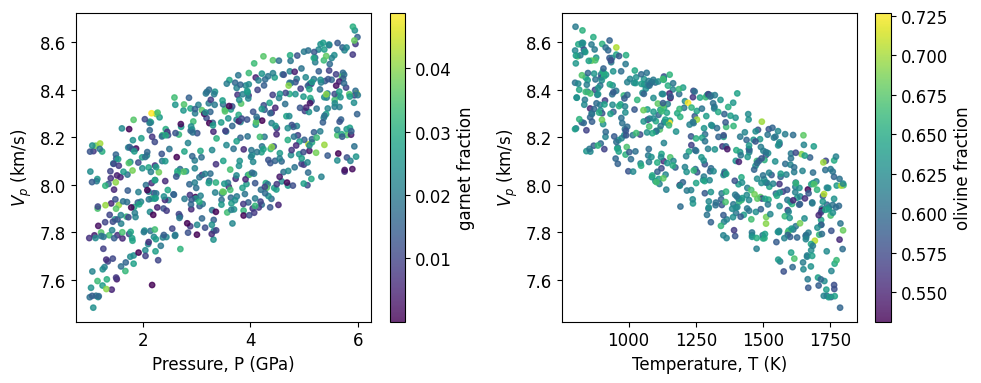

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sc0 = axes[0].scatter(df['P_GPa'], df['Vp_km_s'], c=df['f_gt'], s=15, alpha=0.8)
axes[0].set_xlabel('Pressure, P (GPa)')
axes[0].set_ylabel(r'$V_p$ (km/s)')
fig.colorbar(sc0, ax=axes[0], label='garnet fraction')

sc1 = axes[1].scatter(df['T_K'], df['Vp_km_s'], c=df['f_ol'], s=15, alpha=0.8)
axes[1].set_xlabel('Temperature, T (K)')
axes[1].set_ylabel(r'$V_p$ (km/s)')
fig.colorbar(sc1, ax=axes[1], label='olivine fraction')

plt.tight_layout()
plt.show()

Both plots show the expected trends with $P$ and $T$, but at fixed $P$ or $T$ there is still a spread caused by the varying modal mineralogy (indicated by the color of the points). To capture how all inputs (four mineral fractions, $P$, $T$) jointly control the outputs, we use random forests which are well suited for this kind of nonlinear, multi-variable problem.

### Step 2. Setup and train the model

The input features are the four modal fractions plus $P$ and $T$; the targets are density, $V_p$, and $V_s$. Since we want to predict three properties (density, $V_p$, and $V_s$) at once, we take advantage of the fact that `RandomForestRegressor` in `scikit-learn` natively supports multi-output regression, i.e.,  a single forest can predict all three targets simultaneously.

In [ ]:
feature_cols = ['f_ol', 'f_opx', 'f_cpx', 'f_gt', 'P_GPa', 'T_K']
target_cols  = ['density_g_cm3', 'Vp_km_s', 'Vs_km_s']

X = df[feature_cols].values
y = df[target_cols].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=8)

rf_model = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=2,
    random_state=8
)
rf_model.fit(X_train, y_train)

y_pred_test = rf_model.predict(X_test)

# check the model fit by comparing to the actual values
print(f"{'Property':<16}{'Test RMSE':>12}{'Test R2':>12}")
for i, name in enumerate(target_cols):
    rmse = np.sqrt(mean_squared_error(y_test[:, i], y_pred_test[:, i]))
    r2 = r2_score(y_test[:, i], y_pred_test[:, i])
    print(f"{name:<16}{rmse:>12.4f}{r2:>12.4f}")

Property           Test RMSE     Test R2
density_g_cm3         0.0077      0.9788
Vp_km_s               0.0301      0.9852
Vs_km_s               0.0146      0.9859


The RMSE and R-squared tests values show that the model has learned the relationship between the input features (X, P, T) and the output variables (density, Vp, and Vs) reasonably well.

Let's visualize the predicted vs. real values of the variables to better understand the model's performance.

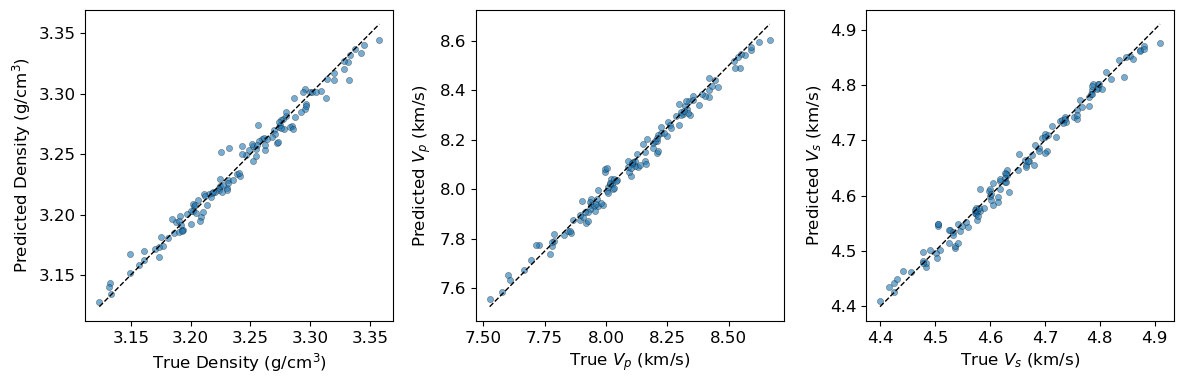

In [ ]:
# Visualize the fits
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
labels = [r'Density ($\mathrm{g/cm^3}$)', r'$V_p$ (km/s)', r'$V_s$ (km/s)']

for i, (ax, label) in enumerate(zip(axes, labels)):
    ax.scatter(y_test[:, i], y_pred_test[:, i], s=20, alpha=0.6, edgecolor='k', linewidth=0.3)
    lims = [min(y_test[:, i].min(), y_pred_test[:, i].min()),
            max(y_test[:, i].max(), y_pred_test[:, i].max())]
    ax.plot(lims, lims, 'k--', linewidth=1)
    ax.set_xlabel(f'True {label}')
    ax.set_ylabel(f'Predicted {label}')

plt.tight_layout()
plt.show()

The black dotted line above represents the perfect prediction line, where the predicted values match the true values exactly. The close proximity of our predictions confirm our model's robustness.

### Feature importance
Since the forest was trained jointly on all three targets, scikit-learn returns one importance value per feature that are summed across outputs, not split out per property. To get importances per property (density, Vp, Vs separately), we need to train three separate single-output forests instead.

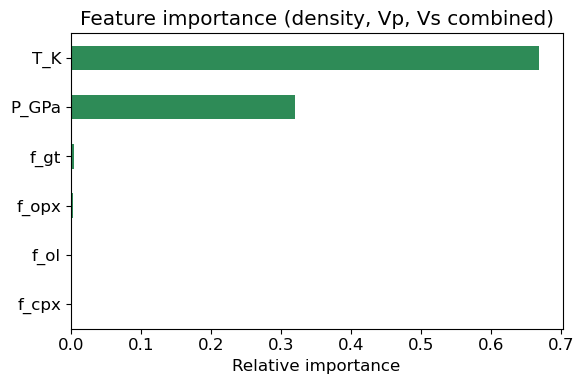

In [ ]:
#--------------Feature importance---------------
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values()

plt.figure(figsize=(6, 4))
importances.plot(kind='barh', color='seagreen')
plt.xlabel('Relative importance')
plt.title('Feature importance (density, Vp, Vs combined)')
plt.tight_layout()
plt.show()

Temperature and pressure dominate the importances, since both directly control the density and elastic moduli of every phase. Among the compositional variables, the garnet fraction is most important. This is consistent with our prior knowledge of garnet being significantly denser and stiffer than the other three phases. The relative proportions of olivine, orthopyroxene, and clinopyroxene matter comparatively little over the range of peridotitic compositions we sampled.

### Step 3. Predicting properties of other rock types

Finally, let's use the trained model to predict the properties of a few real rock types and compare with the BurnMan calculation:

- **lherzolite** and **dunite**: both peridotite compositions, well within the range of modal fractions used for training,
- **eclogite**: a dense, high-pressure metamorphic rock composed almost entirely of garnet and clinopyroxene. This modal combination was never seen during training, and
- **garnetite**: a hypothetical, unrealistic end-member composed entirely of garnet.

In [ ]:
test_rocks = {
    'lherzolite': [0.60, 0.20, 0.15, 0.05],
    'dunite '   : [0.95, 0.03, 0.01, 0.01],
    'eclogite'  : [0.00, 0.05, 0.55, 0.40],
    'garnetite' : [0.00, 0.00, 0.00, 1.00],
}

def true_vs_predicted(rf_model, fractions, P_GPa, T_K):
    """Compare a rock's true (density, Vp, Vs) against the random forest prediction."""
    fractions = np.asarray(fractions, dtype=float)

    rock.set_fractions(fractions)
    rock.set_state(P_GPa * 1e9, T_K)

    true_vals = np.array([
        rock.density / 1e3,
        rock.v_p / 1e3,
        rock.v_s / 1e3,
    ])

    features = [*fractions, P_GPa, T_K]
    pred_vals = rf_model.predict([features])[0]

    percent_err = 100 * (pred_vals - true_vals) / true_vals
    return true_vals, pred_vals, percent_err

In [ ]:
# Store the true and predicted values in a dataframe to plot the differences later
results = []

# Our original pressure and temperature space had 600 points, let's use 50 points
# at random for faster computation
points = rng.integers(0, 600, size=50)

for name, fraction in test_rocks.items():
    for i in points:
        true_vals, pred_vals, percent_err = true_vs_predicted(rf_model, fraction, P_GPa[i], T_K[i])
        results.append([name, P_GPa[i], T_K[i], *true_vals, *pred_vals, *percent_err])

# add the respective header to the column
columns = [
    "rock", "P_GPa", "T_K",
    "true_density", "true_vp", "true_vs",
    "pred_density", "pred_vp", "pred_vs",
    "err_density", "err_vp", "err_vs",
]
results_df = pd.DataFrame(results, columns=columns)

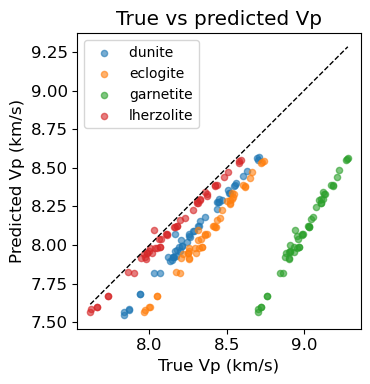

In [ ]:
# We only plot the predicted Vp velocities for each rock
fig, ax = plt.subplots(figsize=(5, 4))

for name, group in results_df.groupby("rock"):
    ax.scatter(group["true_vp"], group["pred_vp"], label=name, alpha=0.6, s=20)

lims = [results_df["true_vp"].min(), results_df["true_vp"].max()]
ax.plot(lims, lims, "k--", linewidth=1)

ax.set_xlabel("True Vp (km/s)")
ax.set_ylabel("Predicted Vp (km/s)")
ax.set_title("True vs predicted Vp")
ax.legend(fontsize=10)
ax.set_aspect("equal")
fig.tight_layout()
plt.show()

As we expected, the farther a rock is from the mean composition of the training data, the less accurate the predictions are. That is, Vp values of lherzolite which is just at the edge of the data distribution are predicted reasonably well. On the other hand, Vp values of garnetite deviate furthest from the true values as the random forest model has never seen this composition type during training.

This suggests that random forests cannot model the underlying physical processes that govern the behavior of rocks outside the range of their training data, and their predictions become progressively less reliable as inputs move away from the training data.

### Try it yourself

- Plot the predictions for Vs and density in the above cell. Do you observe a similar behavior in the predictions for each rock type?
- Change the mean values of mineral compositions in the training data (e.g., `[0.62, 0.24, 0.12, 0.02]` to `[0.9, 0.1, 0, 0]` for an even more olivine-dominated dataset). How does this affect the model's accuracy for the eclogite prediction?
- Change the mean values of mineral compositions in the training data (e.g., `[0.62, 0.24, 0.12, 0.02]` to `[0.45, 0.10, 0.15, 0.30]` for a more garnet-rich dataset). Fertile mantle compositions (e.g., pyrolite) contain more garnet and clinopyroxene than depleted peridotites, because they have not lost these phases through melt extraction. How does shifting the training distribution toward garnet-rich compositions affect the model's accuracy for the eclogite prediction?
- Train three separate single-output `RandomForestRegressor` models (one per property) and compare their individual `feature_importances_`. Does pressure or temperature still dominate for all three properties?

#### References
- McDonough, W. F., & Rudnick, R. L. (1998). Mineralogy and composition of the upper mantle. Reviews in mineralogy, [37, 139-164](https://www.researchgate.net/profile/Roberta-Rudnick/publication/284507003_Mineralogy_and_composition_of_the_upper_mantle/links/565c801208ae1ef92981e5cd/Mineralogy-and-composition-of-the-upper-mantle.pdf?_sg%5B0%5D=started_experiment_milestone&origin=journalDetail).
- Stixrude, L., & Lithgow-Bertelloni, C. (2005). Thermodynamics of mantle minerals—I. Physical properties. Geophysical Journal International, 162(2), [610-632](https://academic.oup.com/gji/article/162/2/610/2051140).
- Stixrude, L., & Lithgow-Bertelloni, C. (2011). Thermodynamics of mantle minerals-II. Phase equilibria. Geophysical Journal International, 184(3), [1180-1213](https://academic.oup.com/gji/article/184/3/1180/607522).
- Myhill, R., Cottaar, S., Heister, T., Rose, I., Unterborn, C., Dannberg, J., & Keller, T. (2023). BurnMan – a Python toolkit for planetary geophysics, geochemistry and thermodynamics. Journal of Open Source Software, [8(90), 5389](https://www.repository.cam.ac.uk/bitstreams/a9be9999-62a8-4207-acf2-5aa9160f4e01/download).